# Baseline U-Net

Loss Function: CrossEntropy

Optimizer: Adam, LR = 1e-4

Evaluation Metric: Mean IoU

Training Details: 8 epochs, locally

## Set up

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset
from PIL import Image

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


In [3]:
from Damage_Assessment_on_xBD.Preprocessing.xBD_splits import create_splits
img_dir = r"../Preprocessing/tiles/images"
mask_dir = r"../Preprocessing/tiles/masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)

# Print sample train files
print(train_files[:8])

Train: 12016
Val: 84
Test: 1592
['palu-tsunami_00000000_post_disaster_0_0.tif', 'palu-tsunami_00000000_post_disaster_0_512.tif', 'palu-tsunami_00000000_post_disaster_512_0.tif', 'palu-tsunami_00000000_post_disaster_512_512.tif', 'palu-tsunami_00000000_pre_disaster_0_0.tif', 'palu-tsunami_00000000_pre_disaster_0_512.tif', 'palu-tsunami_00000000_pre_disaster_512_0.tif', 'palu-tsunami_00000000_pre_disaster_512_512.tif']


In [4]:
# Prediction Task: 5-Class Panoptic Segmentation Problem (0 - 4)
num_classes = 5

In [5]:
# Model Input 3 RGB Channel from pre, 3 RGB from post
input_channels = 6

In [6]:
# Dataset Class (Function w/ assistance from LLM)
class XBDDataset(Dataset):
    def __init__(self, file_list, img_dir, mask_dir):
        self.file_list = file_list
        self.img_dir = img_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        post_name = self.file_list[idx]
        pre_name = post_name.replace("post_disaster", "pre_disaster")

        pre_path = os.path.join(self.img_dir, pre_name)
        post_path = os.path.join(self.img_dir, post_name)
        mask_path = os.path.join(self.mask_dir, post_name)

        pre = np.array(Image.open(pre_path)).astype(np.float32)
        post = np.array(Image.open(post_path)).astype(np.float32)
        mask = np.array(Image.open(mask_path)).astype(np.int64)

        # Normalize to [0,1]
        pre /= 255.0
        post /= 255.0

        # Transpose HWC -> CHW
        pre = np.transpose(pre, (2, 0, 1))
        post = np.transpose(post, (2, 0, 1))

        # Stack pre and post
        image = np.concatenate([pre, post], axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [7]:
# Dataloaders
train_dataset = XBDDataset(train_files, img_dir, mask_dir)
val_dataset = XBDDataset(val_files, img_dir, mask_dir)
test_dataset = XBDDataset(test_files, img_dir, mask_dir)

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

In [9]:
# Sanity Checks on Batch Sizes
images, masks = next(iter(train_loader))
print(images.shape)  # [B, 6, H, W]
print(masks.shape)   # [B, H, W]
print(masks.min(), masks.max())

torch.Size([4, 6, 512, 512])
torch.Size([4, 512, 512])
tensor(0) tensor(1)


## Baseline U-Net Model definition and training

In [10]:
# Baseline Model U-Net, Code Provided by LLM
class ConvBlock(nn.Module):
    """Two 3x3 convolutions each followed by BatchNorm and ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=6, num_classes=5, base_features=32):
        super().__init__()
        f = base_features  # 32

        # ---------- Encoder ----------
        self.enc1 = ConvBlock(in_channels, f)       # 32
        self.enc2 = ConvBlock(f, f * 2)              # 64
        self.enc3 = ConvBlock(f * 2, f * 4)          # 128
        self.enc4 = ConvBlock(f * 4, f * 8)          # 256

        self.pool = nn.MaxPool2d(2)

        # ---------- Bottleneck ----------
        self.bottleneck = ConvBlock(f * 8, f * 16)   # 512

        # ---------- Decoder ----------
        self.up4 = nn.ConvTranspose2d(f * 16, f * 8, 2, stride=2)
        self.dec4 = ConvBlock(f * 16, f * 8)         # concat → 512 → 256

        self.up3 = nn.ConvTranspose2d(f * 8, f * 4, 2, stride=2)
        self.dec3 = ConvBlock(f * 8, f * 4)          # concat → 256 → 128

        self.up2 = nn.ConvTranspose2d(f * 4, f * 2, 2, stride=2)
        self.dec2 = ConvBlock(f * 4, f * 2)          # concat → 128 → 64

        self.up1 = nn.ConvTranspose2d(f * 2, f, 2, stride=2)
        self.dec1 = ConvBlock(f * 2, f)              # concat → 64 → 32

        # ---------- Output ----------
        self.out_conv = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder + skip connections
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)

In [11]:
# Baseline Model
model = UNet(in_channels=6, num_classes=5, base_features=32).to(device)

In [12]:
# Loss Function with weights (under-represented classes weighted heavier)
#  add Tversky loss * 0.5 to 0.5 * CEL if recall much more important than precision

# From EDA notebook
class_counts = torch.tensor([
    3258249517,
    287893139,
    15076019,
    19138232,
    8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()

weights = 1.0 / torch.sqrt(freqs)   # soft inverse
weights = weights / weights.mean()

class_weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight = class_weights).to(device)

In [13]:
# Optimizer
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr = 1e-4)

In [14]:
def compute_metrics(preds, targets, num_classes=5):
    """Compute per-class IoU and overall accuracy."""
    ious = []
    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)
        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    accuracy = (preds == targets).sum().item() / targets.numel()
    return ious, accuracy

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_ious = []
    all_acc = []

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # [B, 5, H, W]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        ious, acc = compute_metrics(preds, masks, num_classes=5)
        all_ious.append(ious)
        all_acc.append(acc)

    epoch_loss = running_loss / len(loader.dataset)
    mean_ious = np.nanmean(all_ious, axis=0)
    mean_acc = np.mean(all_acc)
    miou = np.nanmean(mean_ious)

    return epoch_loss, mean_ious, miou, mean_acc


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_ious = []
    all_acc = []

    for images, masks in tqdm(loader, desc="Val", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        ious, acc = compute_metrics(preds, masks, num_classes=5)
        all_ious.append(ious)
        all_acc.append(acc)

    epoch_loss = running_loss / len(loader.dataset)
    mean_ious = np.nanmean(all_ious, axis=0)
    mean_acc = np.mean(all_acc)
    miou = np.nanmean(mean_ious)

    return epoch_loss, mean_ious, miou, mean_acc

In [16]:
NUM_EPOCHS = 8
best_val_miou = 0.0
class_names = ["No Damage", "Minor", "Major", "Destroyed", "Unclassified"]

history = {"train_loss": [], "val_loss": [], "train_miou": [], "val_miou": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_ious, train_miou, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_ious, val_miou, val_acc = validate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_miou"].append(train_miou)
    history["val_miou"].append(val_miou)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}")
    print(f"  Train mIoU: {train_miou:.4f}  |  Val mIoU: {val_miou:.4f}")
    print(f"  Train Acc:  {train_acc:.4f}  |  Val Acc:  {val_acc:.4f}")
    print(f"  Per-class IoU (val): ", end="")
    for name, iou in zip(class_names, val_ious):
        print(f"{name}: {iou:.3f}  ", end="")
    print()

    # Save best model
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), "best_unet_baseline.pth")
        print(f"  *** Saved new best model (mIoU={val_miou:.4f}) ***")

                                                         
KeyboardInterrupt



## Model eval

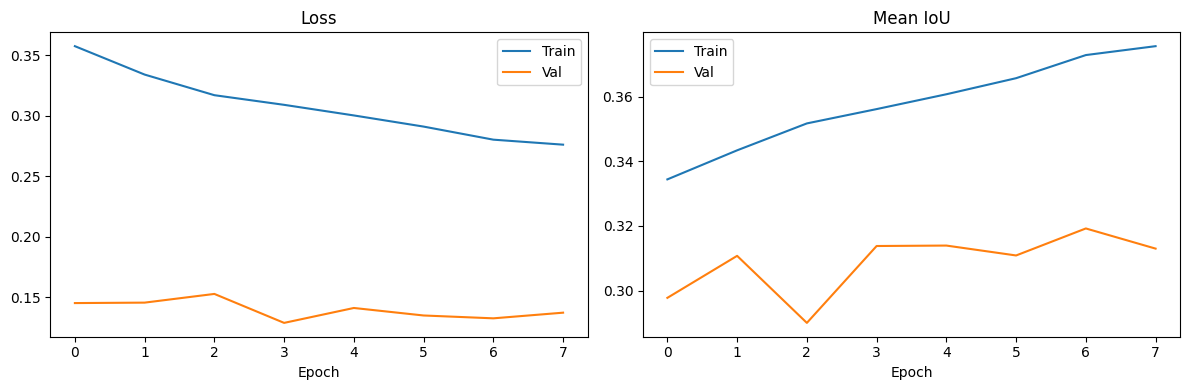

Test Loss: 0.1805
Test mIoU: 0.2785
Test Acc:  0.9644

Per-class IoU:
  No Damage      : 0.9754
  Minor          : 0.3742
  Major          : 0.0172
  Destroyed      : 0.0116
  Unclassified   : 0.0141


In [59]:
import matplotlib.pyplot as plt
from src.visualizations import visualize_predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_miou"], label="Train")
ax2.plot(history["val_miou"], label="Val")
ax2.set_title("Mean IoU")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

# Test Set Evaluation

model.load_state_dict(torch.load("best_unet_baseline.pth"))
test_loss, test_ious, test_miou, test_acc = validate(
    model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test mIoU: {test_miou:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print("\nPer-class IoU:")
for name, iou in zip(class_names, test_ious):
    print(f"  {name:15s}: {iou:.4f}")

In [ ]:
visualize_predictions(model=model, test_loader=test_loader, device=device,
    num_samples=5, title="Siamese U-Net Predictions")

Solid baseline, as expected the model is performing "well" with accuracy and IoU because the majority of the dataset is No Damage/Minor. Need better weighting schema to handle class imbalance. Major, Destroyed, Unclasified barely being detected (low IoUs).